In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia


In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [6]:
data_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'

In [7]:
for split in ['train', 'val', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(data_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} images")

train/NORMAL: 1342 images
train/PNEUMONIA: 3876 images
val/NORMAL: 9 images
val/PNEUMONIA: 9 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


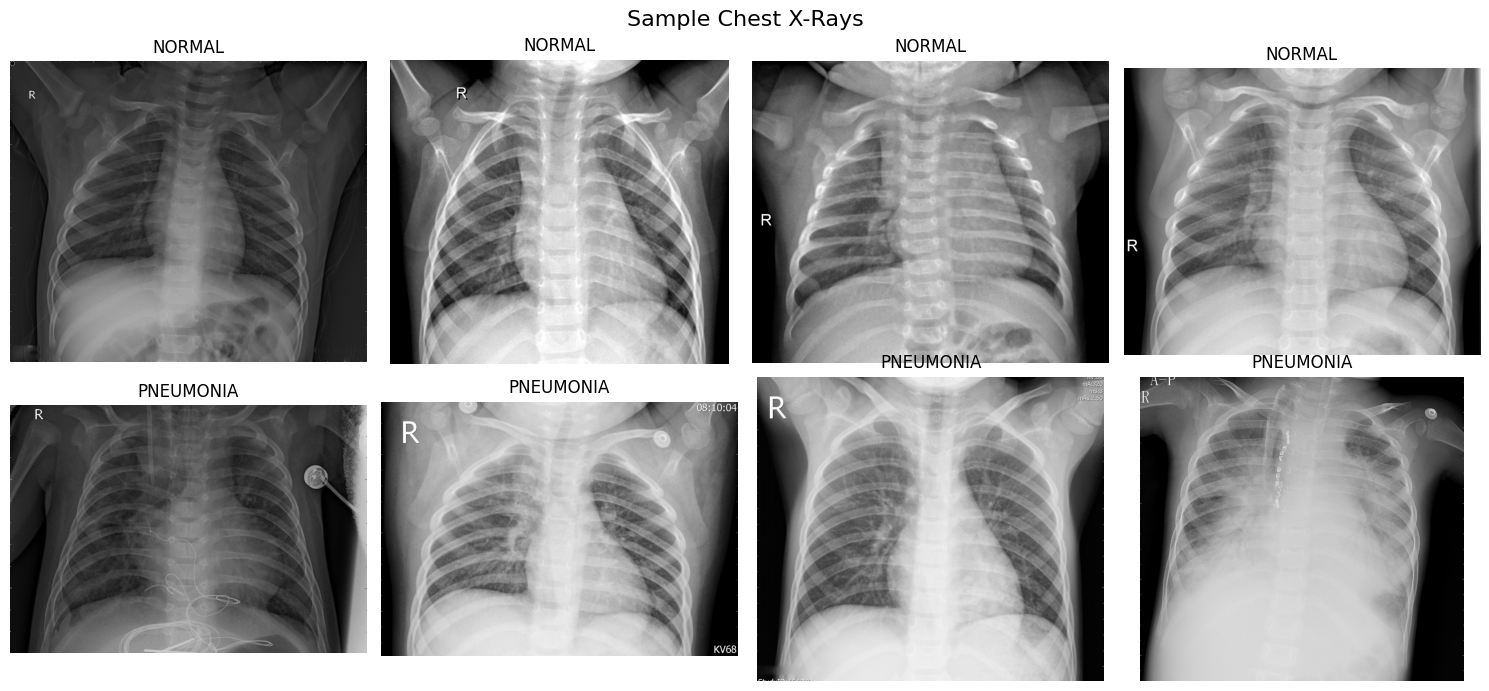

In [9]:
# Visualize some sample X-rays
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle('Sample Chest X-Rays', fontsize=16)

for i, label in enumerate(['NORMAL', 'PNEUMONIA']):
    path = os.path.join(data_dir, 'train', label)
    images = os.listdir(path)[:4]
    
    for j, img_name in enumerate(images):
        img = Image.open(os.path.join(path, img_name)).convert('RGB')
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(label)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Image transforms
# Training: augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),        # resize to 224x224 (standard for pretrained models)
    transforms.RandomHorizontalFlip(),    # randomly flip image
    transforms.RandomRotation(10),        # randomly rotate up to 10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # slight brightness changes
    transforms.ToTensor(),                # convert image to tensor (0-1 range)
    transforms.Normalize(                 # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],      # these values come from ImageNet dataset
        std=[0.229, 0.224, 0.225]        # all pretrained models expect this normalization
    )
])

# Validation/Test: no augmentation, just resize and normalize
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load datasets
train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'train'),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'val'),
    transform=test_transforms
)

test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'test'),
    transform=test_transforms
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Training samples: 5216
Validation samples: 16
Test samples: 624


In [11]:
# Load ResNet50 pretrained on ImageNet
model = models.resnet50(pretrained=True)

# Check original final layer
print("Original final layer:", model.fc)
# Output: Linear(in_features=2048, out_features=1000, bias=True)
# 1000 classes for ImageNet, we need 2 classes (NORMAL/PNEUMONIA)

# FREEZE all layers first - we don't want to change what it already learned
for param in model.parameters():
    param.requires_grad = False

# REPLACE only the final classification layer with our own
# This is fine-tuning - we only train this new layer
model.fc = nn.Sequential(
    nn.Linear(2048, 512),    # reduce from 2048 to 512 features
    nn.ReLU(),               # activation function - adds non-linearity
    nn.Dropout(0.3),         # randomly zero 30% during training - prevents overfitting
    nn.Linear(512, 2)        # final output: 2 classes
)

# Check how many parameters are trainable
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {100*trainable_params/total_params:.2f}%")

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Original final layer: Linear(in_features=2048, out_features=1000, bias=True)

Total parameters: 24,558,146
Trainable parameters: 1,050,114
Trainable percentage: 4.28%


In [13]:
# Loss function and optimizer
# BCEWithLogitsLoss is good for binary classification
criterion = nn.CrossEntropyLoss()

# Only optimize the trainable (final layer) parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Learning rate scheduler - reduces LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print("Training setup complete!")

Training setup complete!


In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=5):
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    
    for epoch in range(epochs):
        # ---- TRAINING PHASE ----
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Print progress every 50 batches
            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        
        # ---- VALIDATION PHASE ----
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  ✓ New best model saved!")
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print("-" * 50)
    
    return train_losses, val_losses, train_accs, val_accs

# Run training
print("Starting training...\n")
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, 
    criterion, optimizer, scheduler, 
    epochs=5
)

Starting training...

  Batch 50/163 - Loss: 0.2825
  Batch 100/163 - Loss: 0.1053
  Batch 150/163 - Loss: 0.2250
  ✓ New best model saved!

Epoch 1/5
  Train Loss: 0.2894 | Train Acc: 87.60%
  Val Loss:   0.2024 | Val Acc:   93.75%
--------------------------------------------------
  Batch 50/163 - Loss: 0.1991
  Batch 100/163 - Loss: 0.1920
  Batch 150/163 - Loss: 0.0597

Epoch 2/5
  Train Loss: 0.1909 | Train Acc: 92.27%
  Val Loss:   0.3433 | Val Acc:   81.25%
--------------------------------------------------
  Batch 50/163 - Loss: 0.4156
  Batch 100/163 - Loss: 0.2552
  Batch 150/163 - Loss: 0.0349

Epoch 3/5
  Train Loss: 0.1723 | Train Acc: 93.21%
  Val Loss:   0.2469 | Val Acc:   93.75%
--------------------------------------------------
  Batch 50/163 - Loss: 0.1130
  Batch 100/163 - Loss: 0.0839
  Batch 150/163 - Loss: 0.1640

Epoch 4/5
  Train Loss: 0.1619 | Train Acc: 93.65%
  Val Loss:   0.6970 | Val Acc:   62.50%
--------------------------------------------------
  Batch 

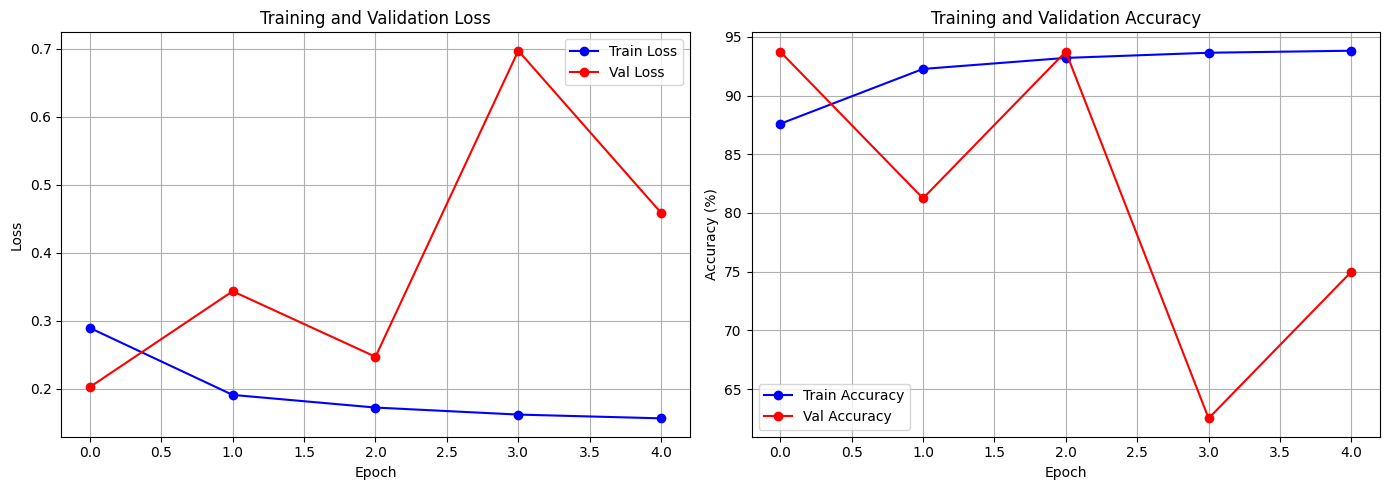

Training curves saved!


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, label='Train Loss', color='blue', marker='o')
ax1.plot(val_losses, label='Val Loss', color='red', marker='o')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(train_accs, label='Train Accuracy', color='blue', marker='o')
ax2.plot(val_accs, label='Val Accuracy', color='red', marker='o')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved!")

In [16]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_predictions = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Classification report
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    all_labels,
    all_predictions,
    target_names=['NORMAL', 'PNEUMONIA']
))

# Overall accuracy
accuracy = 100 * sum(p == l for p, l in zip(all_predictions, all_labels)) / len(all_labels)
print(f"Overall Test Accuracy: {accuracy:.2f}%")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.87      0.71      0.78       234
   PNEUMONIA       0.84      0.94      0.89       390

    accuracy                           0.85       624
   macro avg       0.86      0.82      0.84       624
weighted avg       0.85      0.85      0.85       624

Overall Test Accuracy: 85.26%


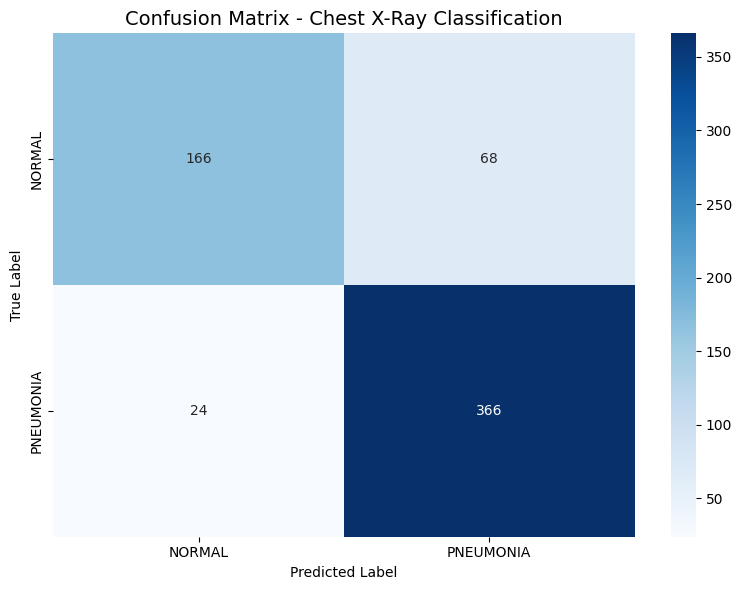


True Negatives  (correctly predicted NORMAL):    166
False Positives (wrongly predicted PNEUMONIA):   68
False Negatives (missed PNEUMONIA cases):        24
True Positives  (correctly detected PNEUMONIA):  366

In medical AI, False Negatives are most dangerous
(missing actual pneumonia cases)


In [17]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)
plt.title('Confusion Matrix - Chest X-Ray Classification', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Explain what confusion matrix means
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted NORMAL):    {tn}")
print(f"False Positives (wrongly predicted PNEUMONIA):   {fp}")
print(f"False Negatives (missed PNEUMONIA cases):        {fn}")
print(f"True Positives  (correctly detected PNEUMONIA):  {tp}")
print(f"\nIn medical AI, False Negatives are most dangerous")
print(f"(missing actual pneumonia cases)")

Testing on Pneumonia X-ray:


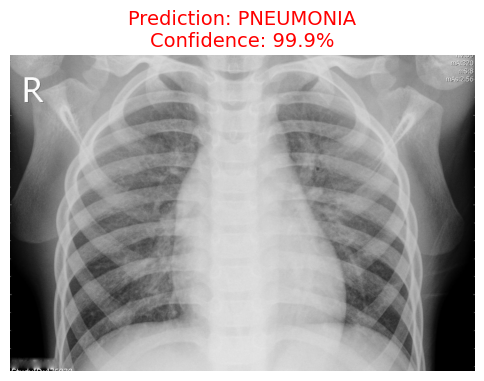

Testing on Normal X-ray:


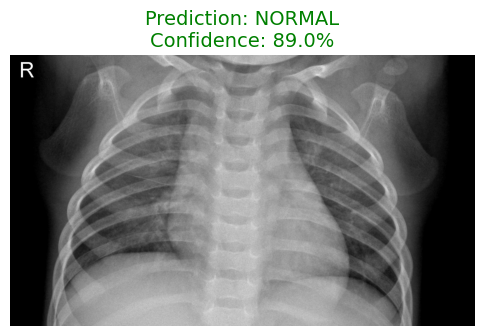

('NORMAL', 88.98367881774902)

In [18]:
def predict_xray(image_path, model, processor_transforms):
    """Predict whether an X-ray shows Pneumonia or Normal"""
    
    image = Image.open(image_path).convert('RGB')
    
    # Apply transforms
    tensor = processor_transforms(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        prob = torch.softmax(output, dim=1)[0]
    
    classes = ['NORMAL', 'PNEUMONIA']
    predicted_class = classes[prob.argmax().item()]
    confidence = prob.max().item() * 100
    
    # Visualize
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.1f}%",
              fontsize=14,
              color='red' if predicted_class == 'PNEUMONIA' else 'green')
    plt.axis('off')
    plt.show()
    
    return predicted_class, confidence

# Test on a sample image
sample_pneumonia = os.path.join(data_dir, 'test', 'PNEUMONIA', 
                                 os.listdir(os.path.join(data_dir, 'test', 'PNEUMONIA'))[0])
sample_normal = os.path.join(data_dir, 'test', 'NORMAL',
                              os.listdir(os.path.join(data_dir, 'test', 'NORMAL'))[0])

print("Testing on Pneumonia X-ray:")
predict_xray(sample_pneumonia, model, test_transforms)

print("Testing on Normal X-ray:")
predict_xray(sample_normal, model, test_transforms)